In [1]:
import json
import pathlib

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import math

from common import (
    INDEX_ORDER as _BASE_INDEX_ORDER,
    index_colors as _base_index_colors,
    index_markers as _base_index_markers,
    transform_duckdb_index_name,
    apply_style,
    save_fig,
    qps_median_ci,
    PLOT_DPI,
    LABEL_FONTSIZE,
    TICK_FONTSIZE,
    TITLE_FONTSIZE,
    MARKER_SIZE,
    FONT_COLOR,
    TICK_FONTS_COLOR,
)

# Toggle to show/hide point ID annotations on scatter plots.
ANNOTATE_POINT_IDS = False

# Toggle to show/hide the normal Global IVF systems (not the 256/cl variants).
SHOW_NORMAL_GLOBAL = False

# ---------------------------------------------------------------------------
# Global IVF approach split: distinguish "pgvector recommendation" (commit
# cbed8a5) from "256 embeddings/cluster" (commit 9b47764) for PDXearch global.
# ---------------------------------------------------------------------------
_COMMIT_256_PER_CLUSTER = "9b47764"

_GLOBAL_256_F32 = "DuckDB PDXearch (IVF, Global 256/cl, F32)"
_GLOBAL_256_U8  = "DuckDB PDXearch (IVF, Global 256/cl, U8)"

try:
    _cmap = plt.colormaps["tab20"]
except (AttributeError, KeyError):
    _cmap = plt.cm.get_cmap("tab20")

# Build local copies with the new index entries.
INDEX_ORDER = []
for idx in _BASE_INDEX_ORDER:
    INDEX_ORDER.append(idx)
    # Insert the 256/cluster variant right after the corresponding global entry.
    if idx == "DuckDB PDXearch (IVF, Global, F32)":
        INDEX_ORDER.append(_GLOBAL_256_F32)
    elif idx == "DuckDB PDXearch (IVF, Global, U8)":
        INDEX_ORDER.append(_GLOBAL_256_U8)

if not SHOW_NORMAL_GLOBAL:
    _NORMAL_GLOBAL = {
        "DuckDB PDXearch (IVF, Global, F32)",
        "DuckDB PDXearch (IVF, Global, U8)",
    }
    INDEX_ORDER = [idx for idx in INDEX_ORDER if idx not in _NORMAL_GLOBAL]

index_colors = dict(_base_index_colors)
index_colors[_GLOBAL_256_F32] = _cmap(4)
index_colors[_GLOBAL_256_U8]  = _cmap(5)

index_markers = dict(_base_index_markers)
index_markers[_GLOBAL_256_F32] = "h"   # hexagon — distinct from Diamond (D)
index_markers[_GLOBAL_256_U8]  = "H"


def _local_transform_index_name(db_case_cfg: dict, db_label: dict) -> str:
    """Like transform_duckdb_index_name but splits Global by commit hash."""
    global_version = db_label.get("global_version", None)
    base = transform_duckdb_index_name(db_case_cfg, global_version)
    # Only remap Global entries that came from the 256/cluster commit.
    if global_version is not None and db_label.get("pdxearch") == _COMMIT_256_PER_CLUSTER:
        base = base.replace("(IVF, Global,", "(IVF, Global 256/cl,")
    return base


def compute_qps(metrics: dict) -> tuple[float, float, float]:
    """Compute (median_qps, lo_err, hi_err) from serial_latencies via bootstrap."""
    latencies = metrics.get("serial_latencies")
    if not latencies:
        raise ValueError("serial_latencies is missing or empty in metrics")
    return qps_median_ci(latencies)


def get_cohere_dataset_order(entry: dict) -> str:
    """Return the dataset order variant for a CohereFilter result entry."""
    custom = entry["task_config"]["case_config"].get("custom_case", {})
    # New-style: unified field
    order = custom.get("dataset_order")
    if order is not None:
        return order
    # Legacy: cohere-prefixed field
    order = custom.get("cohere_dataset_order")
    if order is not None:
        return order
    return "randomly_shuffled"


def get_cohere_filter_type(custom: dict) -> str | None:
    """Return the filter type, supporting both unified and legacy keys."""
    return custom.get("filter_type") or custom.get("cohere_filter_type")


def lighten(color, amount=0.45):
    """Mix *color* toward white by *amount* (0 = unchanged, 1 = white)."""
    r, g, b, a = mcolors.to_rgba(color)
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount, a)


# ---------------------------------------------------------------------------
# Dataset order definitions for comparison plots.
# Each entry: (key in records_by_order, legend suffix, linestyle, lighten_amount, zorder_base)
# ---------------------------------------------------------------------------
DATASET_ORDERS = [
    ("randomly_shuffled",     "random",    ":",  0.30, 1),
    ("sorted_by_predicate",   "sorted",    "-",  0.00, 9),
]


# ---------------------------------------------------------------------------
# 1. Load all result JSONs
# ---------------------------------------------------------------------------
records_by_order: dict[str, list[dict]] = {
    "randomly_shuffled": [],
    "sorted_by_predicate": [],
}


def _process_duckdb_entry(entry, *, require_blob: bool | None = None):
    """Process one DuckDB result entry and add it to records_by_order."""
    metrics = entry["metrics"]
    task_cfg = entry["task_config"]
    db_cfg = task_cfg["db_config"]
    db_case_cfg = task_cfg["db_case_config"]
    case_cfg = task_cfg["case_config"]

    is_blob = db_case_cfg.get("use_blob_interface", False)
    if require_blob is True and not is_blob:
        return
    if require_blob is False and is_blob:
        return

    custom = case_cfg.get("custom_case", {})
    filter_type = get_cohere_filter_type(custom)
    if filter_type is None:
        return

    db_label = json.loads(db_cfg.get("db_label", "{}"))
    index_name = _local_transform_index_name(db_case_cfg, db_label)

    _qps = compute_qps(metrics)

    record = {
        "recall": metrics["recall"],
        "serial_qps": _qps[0],
        "serial_qps_lo": _qps[1],
        "serial_qps_hi": _qps[2],
        "index": index_name,
        "filter_type": filter_type,
        "db_type": "DuckDB",
        "duckdb_threads": db_cfg.get("duckdb_threads"),
        "source_file": str(path),
    }

    order = get_cohere_dataset_order(entry)
    if order in records_by_order:
        records_by_order[order].append(record)


# --- Blob results: PDXearch & VSS (HNSW) from the _blob directory ---------
duckdb_blob_results_dir = pathlib.Path("../experiments/results/index_filtered_search_cohere_blob/DuckDB")
duckdb_blob_json_files = sorted(
    p for p in duckdb_blob_results_dir.glob("*.json") if not p.name.startswith("muted_")
) if duckdb_blob_results_dir.exists() else []

for path in duckdb_blob_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        db_case_cfg = entry["task_config"]["db_case_config"]
        if db_case_cfg.get("index") == "FLAT":
            continue
        _process_duckdb_entry(entry)

# --- Non-blob results: DuckDB flat (no index) from the regular directory ---
duckdb_results_dir = pathlib.Path("../experiments/results/index_filtered_search_cohere/DuckDB")
duckdb_json_files = sorted(
    p for p in duckdb_results_dir.glob("*.json") if not p.name.startswith("muted_")
) if duckdb_results_dir.exists() else []

for path in duckdb_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        db_case_cfg = entry["task_config"]["db_case_config"]
        if db_case_cfg.get("index") != "FLAT":
            continue
        _process_duckdb_entry(entry, require_blob=False)

# Combine all json file lists for use in later cells
all_duckdb_json_files = duckdb_json_files + duckdb_blob_json_files

for order_name, recs in records_by_order.items():
    if recs:
        print(f"Loaded {len(recs):>4d} {order_name} results")
print(f"  from {len(duckdb_json_files)} DuckDB (non-blob) files "
      f"and {len(duckdb_blob_json_files)} DuckDB (blob) files")
records_by_order["randomly_shuffled"][:3]

Loaded  165 randomly_shuffled results
Loaded  164 sorted_by_predicate results
  from 0 DuckDB (non-blob) files and 329 DuckDB (blob) files


[{'recall': 0.271,
  'serial_qps': 90.86882362902003,
  'serial_qps_lo': 1.4129444709554235,
  'serial_qps_hi': 1.8289465114937684,
  'index': 'DuckDB PDXearch (IVF, Global 256/cl, F32)',
  'filter_type': 'R',
  'db_type': 'DuckDB',
  'duckdb_threads': 14,
  'source_file': '../experiments/results/index_filtered_search_cohere_blob/DuckDB/result_20260403_duckdbpdxearch_CohereFilterPerformanceCase_11-34-22_duckdb.json'},
 {'recall': 0.3754,
  'serial_qps': 91.64590314173613,
  'serial_qps_lo': 1.5511737541888095,
  'serial_qps_hi': 1.4860954381523754,
  'index': 'DuckDB PDXearch (IVF, Global 256/cl, F32)',
  'filter_type': 'R',
  'db_type': 'DuckDB',
  'duckdb_threads': 14,
  'source_file': '../experiments/results/index_filtered_search_cohere_blob/DuckDB/result_20260403_duckdbpdxearch_CohereFilterPerformanceCase_11-48-06_duckdb.json'},
 {'recall': 0.4349,
  'serial_qps': 91.29658265479051,
  'serial_qps_lo': 1.382588083710587,
  'serial_qps_hi': 1.477658465833244,
  'index': 'DuckDB PDXea

In [2]:
# ---------------------------------------------------------------------------
# 2. Assign point IDs
# ---------------------------------------------------------------------------

_pid = 0
for order_name, recs in records_by_order.items():
    for r in recs:
        r["point_id"] = _pid
        _pid += 1

if ANNOTATE_POINT_IDS:
    print(f"{'ID':>4}  {'Order':>25}  {'Recall':>7}  {'QPS':>8}  {'Filter':>5}  {'Index':45s}  {'File'}")
    print("-" * 170)
    for order_name, recs in records_by_order.items():
        for r in recs:
            src = pathlib.Path(r["source_file"]).name
            print(f"{r['point_id']:>4}  {order_name:>25}  {r['recall']:>7.4f}  {r['serial_qps']:>8.1f}  "
                  f"{r['filter_type']:>5}  {r['index']:45s}  {src}")
else:
    print("Point IDs disabled. Set ANNOTATE_POINT_IDS = True in the first cell to enable.")

Point IDs disabled. Set ANNOTATE_POINT_IDS = True in the first cell to enable.


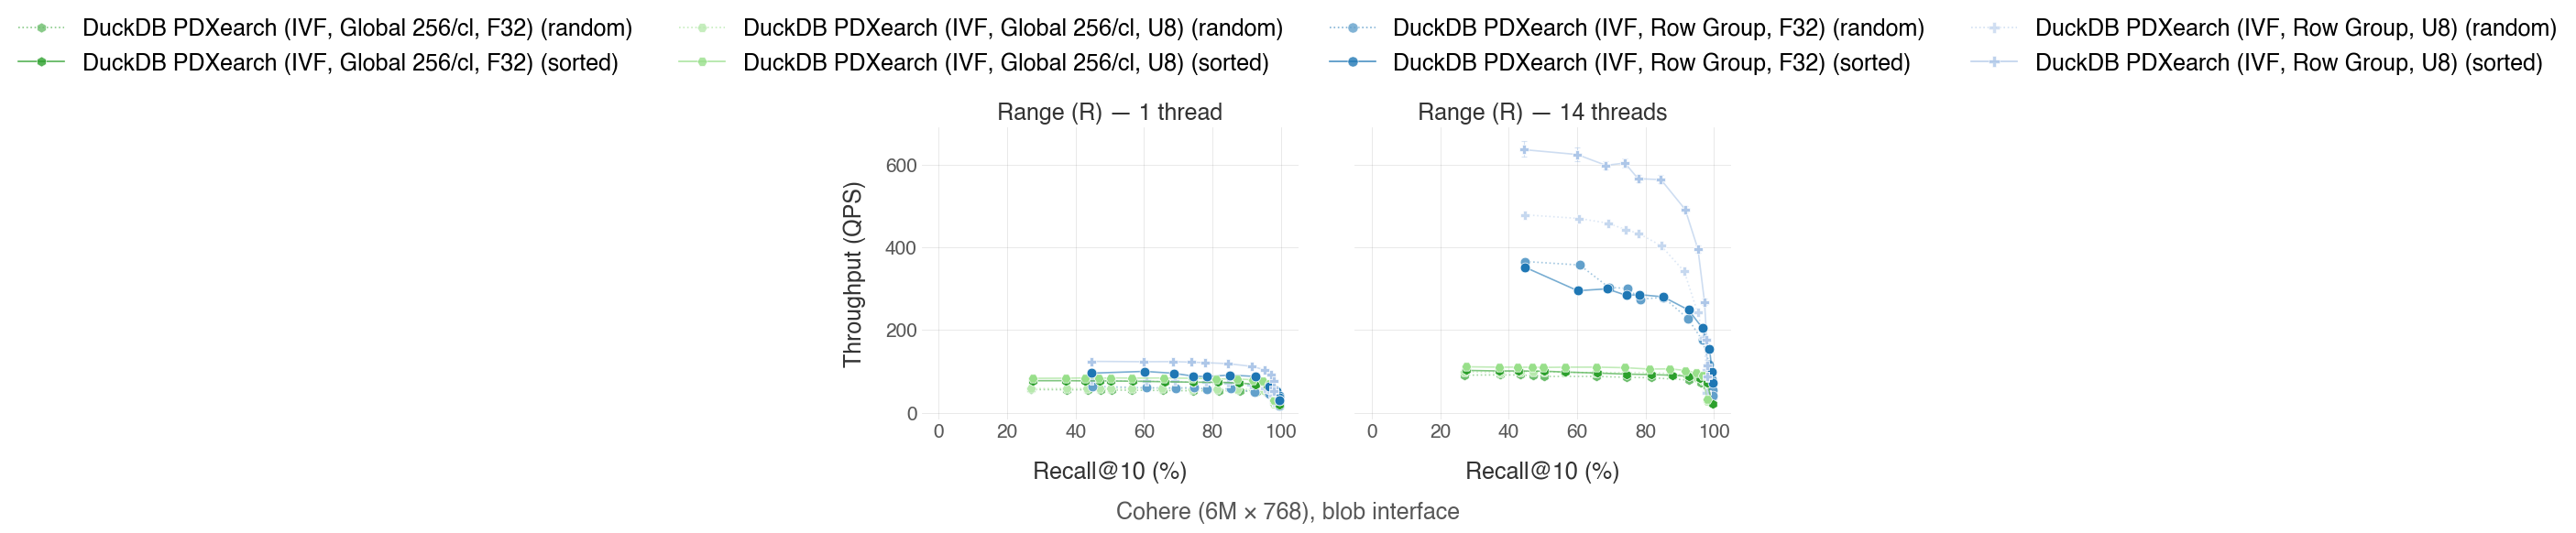

In [3]:
# ---------------------------------------------------------------------------
# 3. Range (R) — overall Recall vs QPS, all dataset orders
#    Two subplots: 1 thread vs 14 threads.
# ---------------------------------------------------------------------------
from collections import defaultdict
from matplotlib.lines import Line2D

apply_style()

THREAD_COUNTS_RANGE = [1, 14]

# Group Range (R) records by thread count and dataset order
range_grouped: dict[int, dict[str, dict[str, list]]] = {}
active_order_keys = {key for key, _, _, _, _ in DATASET_ORDERS}

for tc in THREAD_COUNTS_RANGE:
    range_grouped[tc] = {}
    for order_key in active_order_keys:
        range_grouped[tc][order_key] = defaultdict(list)

for order_key, recs in records_by_order.items():
    if order_key not in active_order_keys:
        continue
    for r in recs:
        if r["filter_type"] != "R":
            continue
        tc = r.get("duckdb_threads")
        if tc not in range_grouped:
            continue
        range_grouped[tc][order_key][r["index"]].append(
            (r["recall"], r["serial_qps"], r["serial_qps_lo"], r["serial_qps_hi"], r.get("point_id", -1))
        )

# Collect all index types present
all_idx_range = set()
for tc in THREAD_COUNTS_RANGE:
    for order_key in active_order_keys:
        all_idx_range.update(range_grouped[tc][order_key].keys())
all_idx_range = [idx for idx in INDEX_ORDER if idx in all_idx_range]

n_cols = len(THREAD_COUNTS_RANGE)
fig, axes = plt.subplots(1, n_cols, figsize=(5.0 * n_cols, 5.0), squeeze=False, sharey=True)

for col_idx, tc in enumerate(THREAD_COUNTS_RANGE):
    ax = axes[0][col_idx]

    for order_key, _, linestyle, lighten_amount, z_base in DATASET_ORDERS:
        data = range_grouped[tc][order_key]
        for index_type in all_idx_range:
            points = data.get(index_type, [])
            if not points:
                continue
            points.sort(key=lambda p: p[0])
            recalls = [p[0] for p in points]
            qps_vals = [p[1] for p in points]
            qps_lo = [p[2] for p in points]
            qps_hi = [p[3] for p in points]
            point_ids = [p[4] for p in points]

            color = lighten(index_colors.get(index_type, "#808080"), lighten_amount)
            marker = index_markers.get(index_type, "o")

            ax.errorbar(recalls, qps_vals, yerr=[qps_lo, qps_hi], fmt="none",
                       ecolor=color, elinewidth=0.8, capsize=2, capthick=0.8, alpha=0.5, zorder=z_base + 1)
            ax.scatter(recalls, qps_vals, color=color, marker=marker, s=MARKER_SIZE,
                       zorder=z_base + 1, edgecolors="white", linewidths=0.5)
            ax.plot(recalls, qps_vals, color=color, linewidth=1.2, alpha=0.6,
                    linestyle=linestyle, zorder=z_base)
            if ANNOTATE_POINT_IDS:
                for _r, _q, _pid in zip(recalls, qps_vals, point_ids):
                    ax.annotate(str(_pid), (_r, _q), fontsize=5, ha="left", va="bottom",
                                color="#333333", xytext=(3, 3), textcoords="offset points", zorder=10)

    label = "thread" if tc == 1 else "threads"
    ax.set_title(f"Range (R) — {tc} {label}", fontsize=TITLE_FONTSIZE, color=FONT_COLOR)
    ax.set_xlabel("Recall@10 (%)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)
    if col_idx == 0:
        ax.set_ylabel("Throughput (QPS)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)

    ax.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xlim(-0.05, 1.05)
    ax.set_xticks([i / 5 for i in range(6)])
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x * 100:.0f}"))
    ax.tick_params(axis='both', colors=TICK_FONTS_COLOR, length=0)
    ax.tick_params(axis='x', labelsize=TICK_FONTSIZE)
    ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)

# Shared legend
legend_handles = []
for index_type in all_idx_range:
    base_color = index_colors.get(index_type, "#808080")
    marker = index_markers.get(index_type, "o")
    for order_key, label_suffix, linestyle, lighten_amount, _ in DATASET_ORDERS:
        has_data = any(
            range_grouped[tc][order_key].get(index_type)
            for tc in THREAD_COUNTS_RANGE
        )
        if not has_data:
            continue
        color = lighten(base_color, lighten_amount)
        legend_handles.append(Line2D([0], [0], color=color, marker=marker, linestyle=linestyle,
                                      markersize=8, markeredgecolor='white', markeredgewidth=0.5,
                                      linewidth=1.2, alpha=0.8, label=f"{index_type} ({label_suffix})"))

if legend_handles:
    fig.legend(handles=legend_handles, loc="upper center",
               ncol=max(1, len(legend_handles) // 2),
               frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, 1.12))


fig.text(0.5, -0.02, "Cohere (6M × 768), blob interface",
         ha="center", fontsize=LABEL_FONTSIZE, color=TICK_FONTS_COLOR)
fig.tight_layout(rect=[0, 0.03, 1, 0.92])
fig.subplots_adjust(wspace=0.15)
save_fig("index_filtered_search_cohere_blob_range_overall")

MAX_QUERIES = 10500
Selectivity bucket ranges (3 buckets):
  B0: 75%–100%  (4000 queries)
  B1: 1.0%–1.0%  (500 queries)
  B2: 0.1%–0.1%  (500 queries)


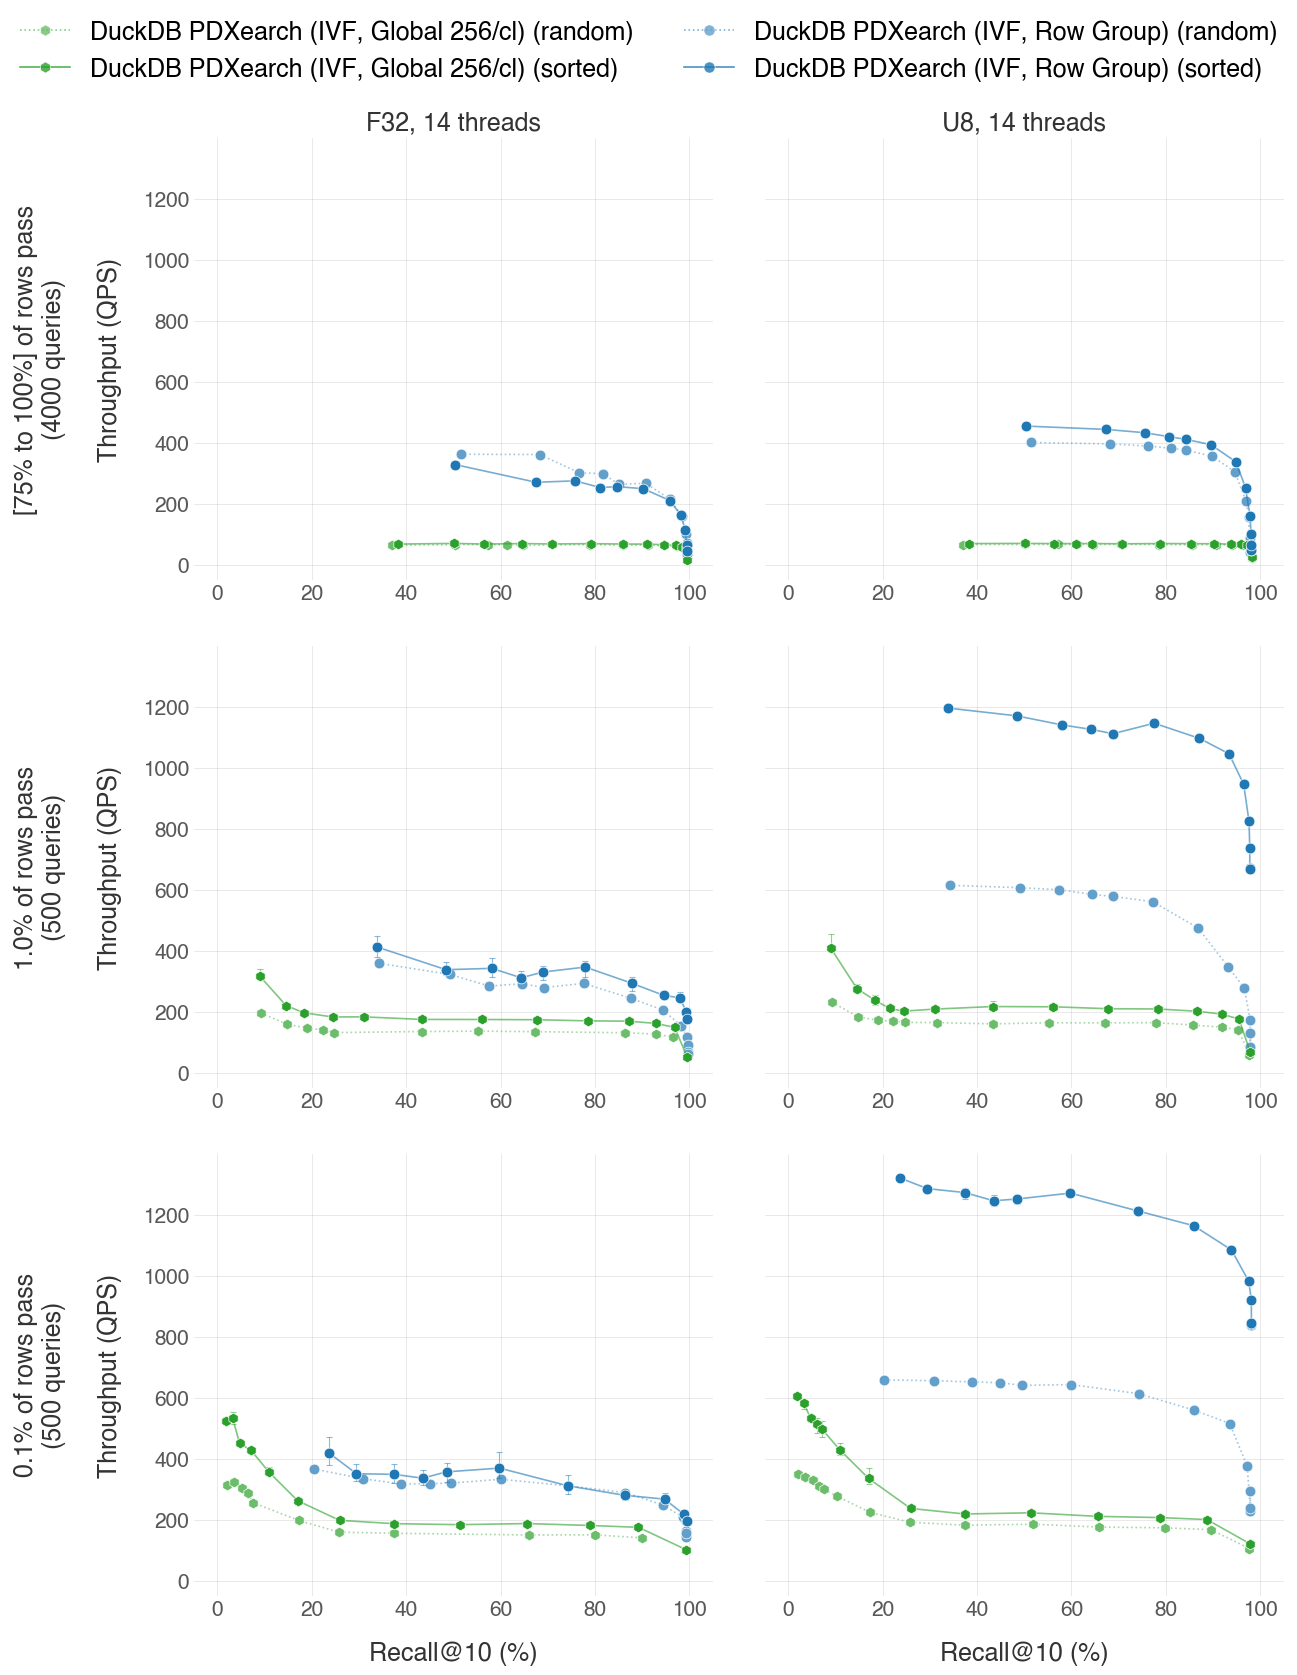

Saved index_filtered_search_cohere_blob_by_selectivity_f32_vs_u8


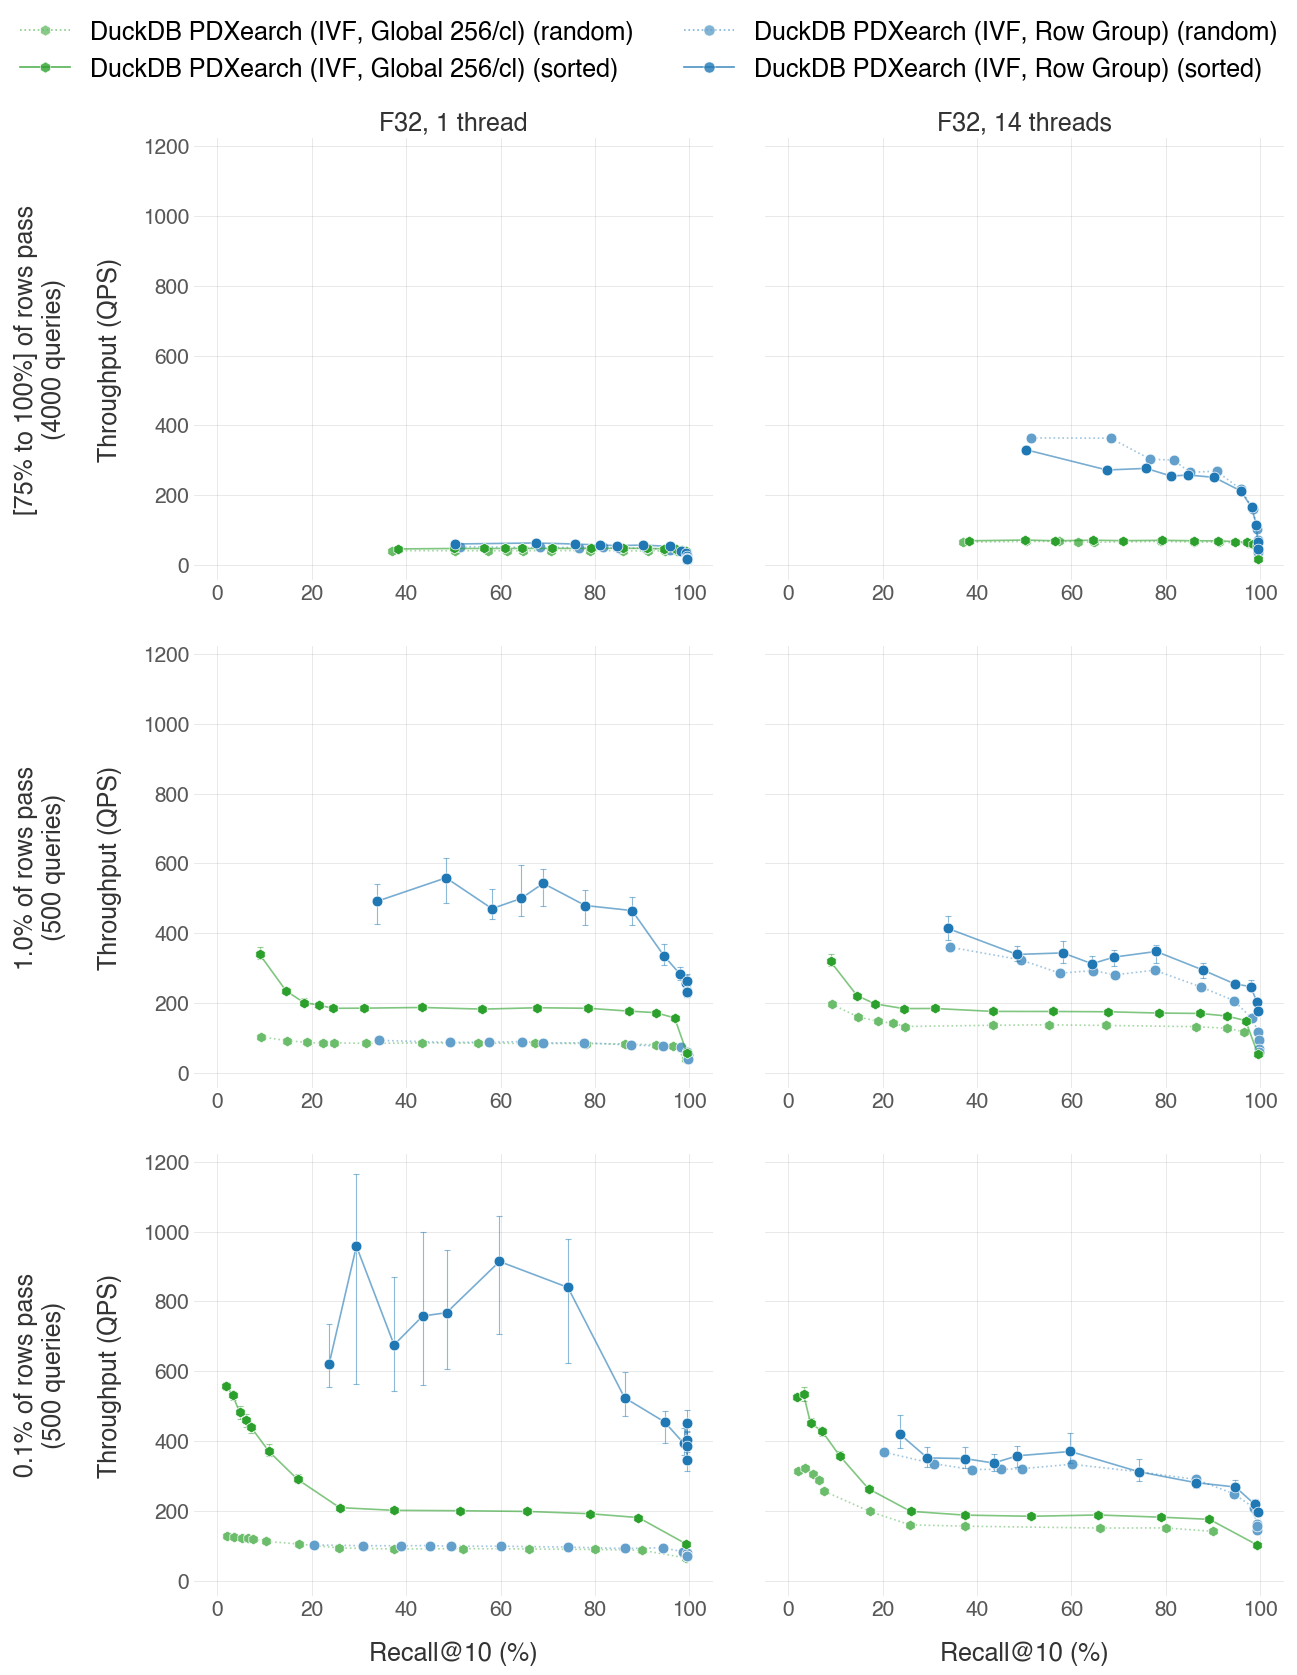

Saved index_filtered_search_cohere_blob_by_selectivity_14t_vs_1t


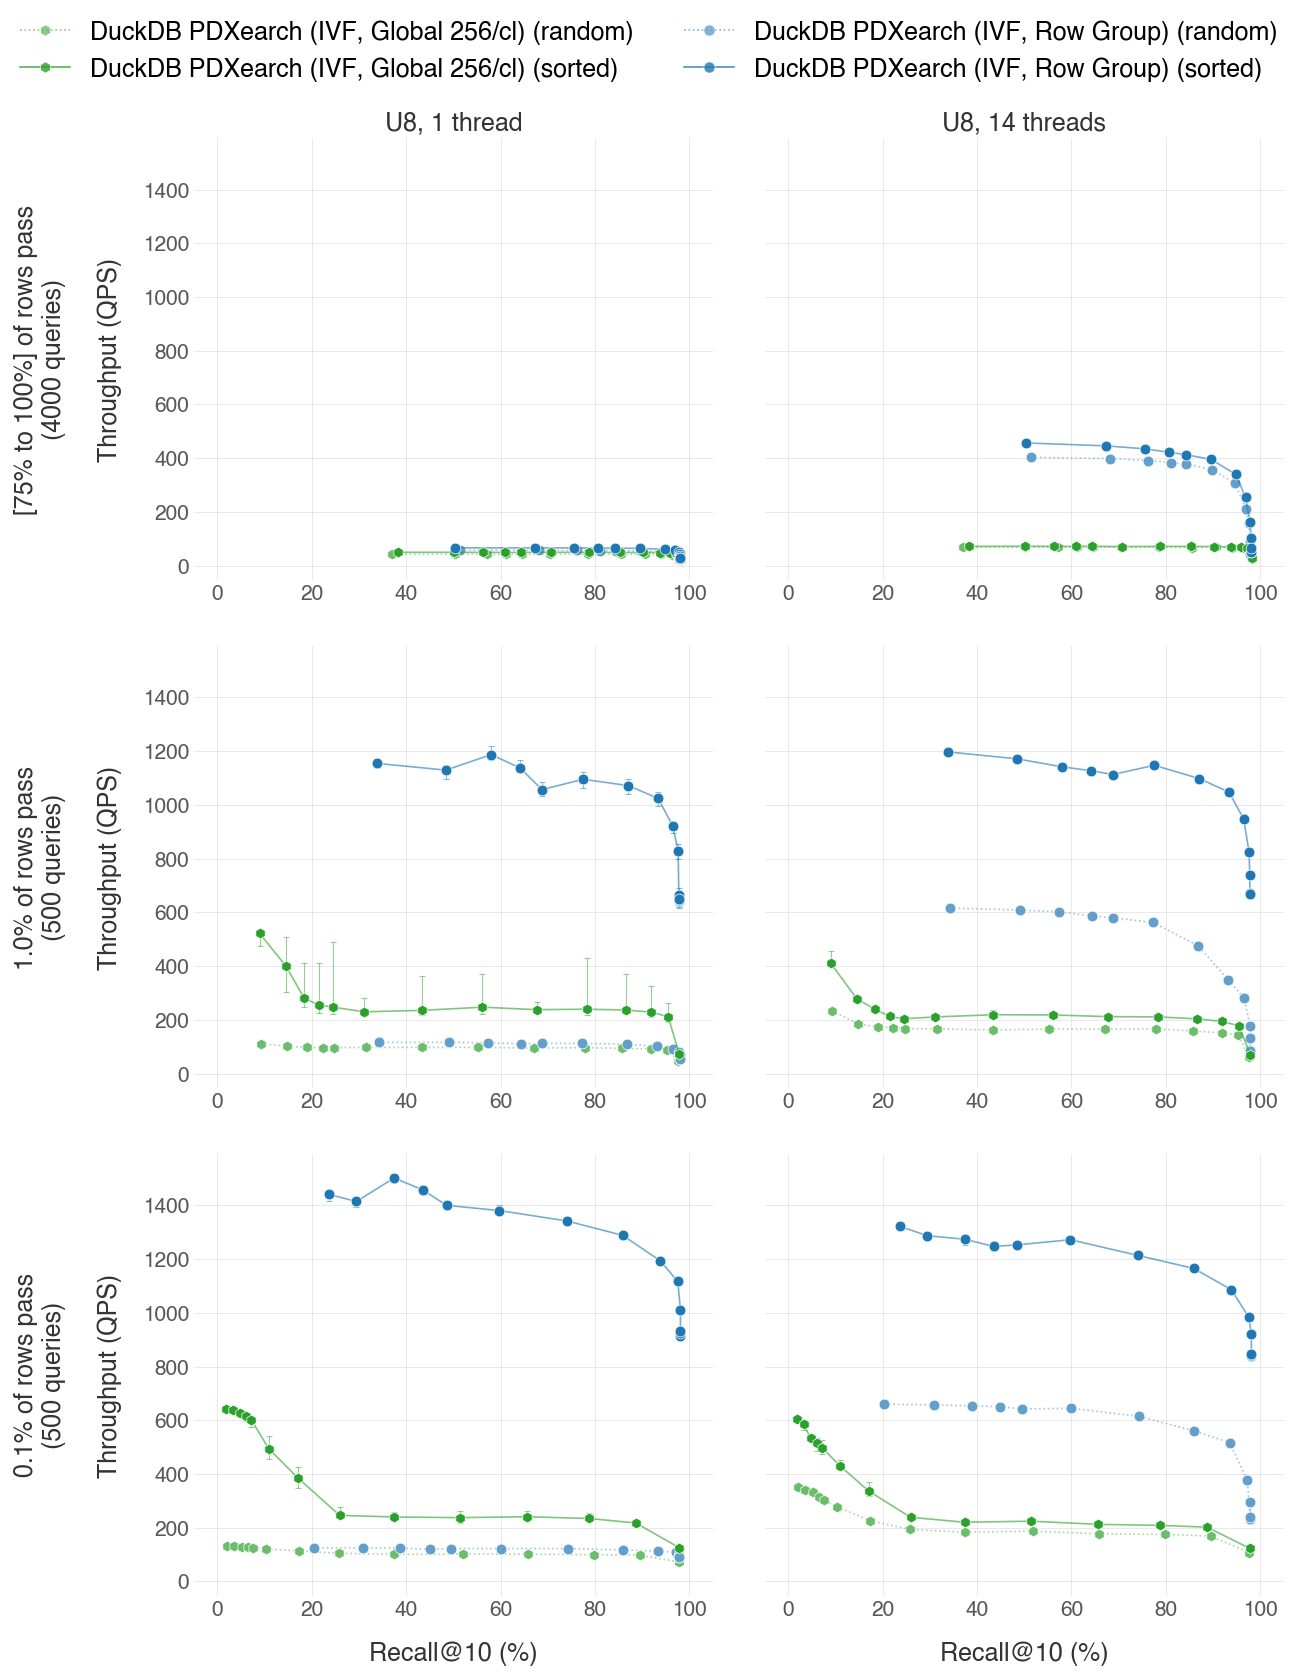

Saved index_filtered_search_cohere_blob_by_selectivity_u8_14t_vs_1t


In [4]:
# ---------------------------------------------------------------------------
# 4. Range (R) QPS by selectivity bucket — all dataset orders
# ---------------------------------------------------------------------------
from collections import defaultdict
from matplotlib.lines import Line2D

apply_style()

# Custom selectivity bucket ranges (percentage of rows that pass the filter).
# Each tuple is (low_pct, high_pct).
BUCKET_RANGES = [
    # (0.4, 0.6),
    (75, 100),
    (1.0, 1.0),
    (0.1, 0.1),
    # (25, 75),
    # (25, 100),
]
NUM_BUCKETS = len(BUCKET_RANGES)
THREAD_COUNTS = [1, 14]

# Load per-query selectivities from the precomputed JSON.
SELECTIVITY_JSON = pathlib.Path(
    "../experiments/results/index_filtered_search_cohere_blob/test_queries_selectivity.json"
)
if not SELECTIVITY_JSON.exists():
    SELECTIVITY_JSON = pathlib.Path(
        "../../vectordb_bench/dataset/c_cohere6m/c_cohere6m_medium_6m/test_queries_selectivity.json"
    )

with open(SELECTIVITY_JSON) as f:
    sel_data = json.load(f)

# Determine MAX_QUERIES from actual result files.
MAX_QUERIES = None
for path in all_duckdb_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        lats = entry.get("metrics", {}).get("serial_latencies", [])
        if lats:
            MAX_QUERIES = len(lats)
            break
    if MAX_QUERIES is not None:
        break

if MAX_QUERIES is None:
    raise ValueError("No valid results with serial_latencies found")
print(f"MAX_QUERIES = {MAX_QUERIES}")

query_selectivities = np.array([q["selectivity"] for q in sel_data["queries"][:MAX_QUERIES]])

# Assign each query to a bucket. A bucket's upper bound is inclusive when
# it's a single-point bucket (lo == hi) or when it reaches 100%.
def _bucket_upper_inclusive(lo, hi):
    return lo == hi or hi == 100

bucket_assignment = np.full(MAX_QUERIES, -1, dtype=int)
for b, (lo, hi) in enumerate(BUCKET_RANGES):
    lo_frac, hi_frac = lo / 100.0, hi / 100.0
    if _bucket_upper_inclusive(lo, hi):
        mask = (query_selectivities >= lo_frac) & (query_selectivities <= hi_frac)
    else:
        mask = (query_selectivities >= lo_frac) & (query_selectivities < hi_frac)
    bucket_assignment[mask] = b

bucket_counts = []
print(f"Selectivity bucket ranges ({NUM_BUCKETS} buckets):")
for b, (lo, hi) in enumerate(BUCKET_RANGES):
    count = int((bucket_assignment == b).sum())
    bucket_counts.append(count)
    print(f"  B{b}: {lo}%–{hi}%  ({count} queries)")

unassigned = int((bucket_assignment == -1).sum())
if unassigned > 0:
    print(f"  WARNING: {unassigned} queries not assigned to any bucket")


def compute_bucket_qps(latencies, bucket_assignment, num_buckets):
    lats = np.array(latencies)
    qps_per_bucket = []
    for b in range(num_buckets):
        mask = bucket_assignment == b
        bucket_lats = lats[mask]
        if len(bucket_lats) == 0:
            qps_per_bucket.append((0.0, 0.0, 0.0))
        else:
            qps_per_bucket.append(qps_median_ci(bucket_lats.tolist()))
    return qps_per_bucket


def compute_bucket_recalls(recalls, bucket_assignment, num_buckets):
    recs = np.array(recalls)
    recall_per_bucket = []
    for b in range(num_buckets):
        mask = bucket_assignment == b
        bucket_recs = recs[mask]
        if len(bucket_recs) == 0:
            recall_per_bucket.append(0.0)
        else:
            recall_per_bucket.append(float(np.mean(bucket_recs)))
    return recall_per_bucket


# Records per bucket per dataset order per thread count
bucket_records: dict[int, dict[str, list[dict[str, list]]]] = {}
active_order_keys = {key for key, _, _, _, _ in DATASET_ORDERS}
for tc in THREAD_COUNTS:
    bucket_records[tc] = {}
    for order_key in active_order_keys:
        bucket_records[tc][order_key] = [defaultdict(list) for _ in range(NUM_BUCKETS)]


def _process_duckdb_bucket_entry(entry, *, index_filter=None, filepath=""):
    metrics = entry["metrics"]
    task_cfg = entry["task_config"]
    db_cfg = task_cfg["db_config"]
    db_case_cfg = task_cfg["db_case_config"]
    case_cfg = task_cfg["case_config"]

    idx = db_case_cfg.get("index", "")
    if index_filter == "FLAT" and idx != "FLAT":
        return
    if index_filter == "EXTENSION" and idx == "FLAT":
        return

    custom = case_cfg.get("custom_case", {})
    filter_type = get_cohere_filter_type(custom)
    if filter_type != "R":
        return

    latencies = metrics.get("serial_latencies", [])
    if len(latencies) != MAX_QUERIES:
        return

    order = get_cohere_dataset_order(entry)
    if order not in active_order_keys:
        return

    threads = db_cfg.get("duckdb_threads")
    if threads not in bucket_records:
        return

    db_label = json.loads(db_cfg.get("db_label", "{}"))
    index_name = _local_transform_index_name(db_case_cfg, db_label)

    per_query_recalls = metrics.get("recalls")
    if per_query_recalls is None or len(per_query_recalls) != MAX_QUERIES:
        return

    qps_list = compute_bucket_qps(latencies, bucket_assignment, NUM_BUCKETS)
    recall_list = compute_bucket_recalls(per_query_recalls, bucket_assignment, NUM_BUCKETS)

    for b in range(NUM_BUCKETS):
        bucket_records[threads][order][b][index_name].append(
            (recall_list[b], qps_list[b][0], qps_list[b][1], qps_list[b][2])
        )


for path in duckdb_blob_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        _process_duckdb_bucket_entry(entry, index_filter="EXTENSION", filepath=str(path))

for path in duckdb_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        _process_duckdb_bucket_entry(entry, index_filter="FLAT", filepath=str(path))


# ---------------------------------------------------------------------------
# Helper: filter bucket_records to only include index names matching a
# quantization type (F32 or U8), optionally remapping names.
# ---------------------------------------------------------------------------
def _filter_bucket_data(thread_counts, quant_filter=None, remap_fn=None):
    """Return (filtered_bucket_records, ordered_index_list).

    quant_filter: if set (e.g. "F32" or "U8"), only include index names
                  containing that substring.
    remap_fn:     if set, applied to index names in the returned data and
                  the ordered list.
    """
    filtered: dict[int, dict[str, list[dict[str, list]]]] = {}
    all_idx = set()
    for tc in thread_counts:
        filtered[tc] = {}
        for order_key in active_order_keys:
            filtered[tc][order_key] = [defaultdict(list) for _ in range(NUM_BUCKETS)]
            for b in range(NUM_BUCKETS):
                for idx_name, points in bucket_records[tc][order_key][b].items():
                    if quant_filter and quant_filter not in idx_name:
                        continue
                    out_name = remap_fn(idx_name) if remap_fn else idx_name
                    filtered[tc][order_key][b][out_name] = points
                    all_idx.add(out_name)
    # Use INDEX_ORDER for consistent ordering; also try remapped names.
    if remap_fn:
        order_list = []
        seen = set()
        for idx in INDEX_ORDER:
            remapped = remap_fn(idx)
            for name in (idx, remapped):
                if name in all_idx and name not in seen:
                    order_list.append(name)
                    seen.add(name)
        ordered = order_list
    else:
        ordered = [idx for idx in INDEX_ORDER if idx in all_idx]
    return filtered, ordered


# ---------------------------------------------------------------------------
# Plotting helper
# ---------------------------------------------------------------------------
def plot_selectivity_buckets(
    row_configs,
    all_idx_ordered,
    filtered_records,
    legend_handles,
    filename,
):
    """Plot selectivity-bucket scatter.

    Layout: rows = selectivity buckets, columns = configs (e.g. F32/U8 or
    1T/14T). The buckets become row labels (left), and the configs become
    column titles (top).

    row_configs: list of (thread_count, label) per column. Kept as
    `row_configs` for backward compatibility with existing call sites.
    """
    n_cols = len(row_configs)
    n_rows = NUM_BUCKETS
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(6.5 * n_cols, 5.5 * n_rows),
                             squeeze=False, sharey=True)

    for col_idx, (tc, col_label) in enumerate(row_configs):
        for b in range(NUM_BUCKETS):
            ax = axes[b][col_idx]
            lo, hi = BUCKET_RANGES[b]

            for order_key, _, linestyle, lighten_amount, z_base in DATASET_ORDERS:
                bdata = filtered_records[tc][order_key][b]
                for index_type in all_idx_ordered:
                    points = bdata.get(index_type, [])
                    if not points:
                        continue
                    points_s = sorted(points, key=lambda p: p[0])
                    recalls = [p[0] for p in points_s]
                    qps_vals = [p[1] for p in points_s]
                    qps_lo = [p[2] for p in points_s]
                    qps_hi = [p[3] for p in points_s]
                    color = lighten(index_colors.get(index_type, "#808080"), lighten_amount)
                    marker = index_markers.get(index_type, "o")
                    ax.errorbar(recalls, qps_vals, yerr=[qps_lo, qps_hi], fmt="none",
                               ecolor=color, elinewidth=0.8, capsize=2, capthick=0.8,
                               alpha=0.5, zorder=z_base + 1)
                    ax.scatter(recalls, qps_vals, color=color, marker=marker, s=MARKER_SIZE,
                               zorder=z_base + 1, edgecolors="white", linewidths=0.5)
                    ax.plot(recalls, qps_vals, color=color, linewidth=1.2, alpha=0.6,
                            linestyle=linestyle, zorder=z_base)

            if b == 0:
                ax.set_title(col_label, fontsize=TITLE_FONTSIZE, color=FONT_COLOR)

            if b == n_rows - 1:
                ax.set_xlabel("Recall@10 (%)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)

            if col_idx == 0:
                if lo == hi:
                    bucket_label = f"{lo}% of rows pass\n({bucket_counts[b]} queries)"
                elif _bucket_upper_inclusive(lo, hi):
                    bucket_label = f"[{lo}% to {hi}%] of rows pass\n({bucket_counts[b]} queries)"
                else:
                    bucket_label = f"[{lo}% to {hi}%) of rows pass\n({bucket_counts[b]} queries)"
                ax.set_ylabel(f"{bucket_label}\n\nThroughput (QPS)",
                              fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)

            ax.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
            ax.set_axisbelow(True)
            for spine in ax.spines.values():
                spine.set_visible(False)
            ax.set_xlim(-0.05, 1.05)
            ax.set_xticks([i / 5 for i in range(6)])
            ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x * 100:.0f}"))
            ax.tick_params(axis='both', colors=TICK_FONTS_COLOR, length=0)
            ax.tick_params(axis='x', labelsize=TICK_FONTSIZE)
            ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)

    if legend_handles:
        fig.legend(handles=legend_handles, loc="upper center",
                   ncol=max(1, len(legend_handles) // 2),
                   frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, 1.02))

    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.subplots_adjust(wspace=0.10, hspace=0.15)
    save_fig(filename)
    plt.show()
    print(f"Saved {filename}")


# ---------------------------------------------------------------------------
# PDF 1: F32 (14T) vs U8 (14T)
#
# Strip the quantization suffix (", F32" / ", U8") from index names so that
# U8 rows reuse the same colors/markers as F32.
# ---------------------------------------------------------------------------
def _strip_quant(name: str) -> str:
    """Remove trailing ', F32)' or ', U8)' → ')' from index display names."""
    for suffix in (", F32)", ", U8)"):
        if name.endswith(suffix):
            return name[: -len(suffix)] + ")"
    return name

# Register stripped (quant-free) names so they resolve to the F32 colors/markers.
for _orig_name in list(index_colors):
    _stripped = _strip_quant(_orig_name)
    if _stripped != _orig_name and _stripped not in index_colors:
        index_colors[_stripped] = index_colors[_orig_name]
for _orig_name in list(index_markers):
    _stripped = _strip_quant(_orig_name)
    if _stripped != _orig_name and _stripped not in index_markers:
        index_markers[_stripped] = index_markers[_orig_name]


f32_14_data, f32_14_idx = _filter_bucket_data([14], quant_filter="F32", remap_fn=_strip_quant)
u8_14_data, u8_14_idx = _filter_bucket_data([14], quant_filter="U8", remap_fn=_strip_quant)

# Merge ordered index lists (F32 set is superset in practice)
seen = set()
quant_idx_ordered = []
for idx in f32_14_idx + u8_14_idx:
    if idx not in seen:
        quant_idx_ordered.append(idx)
        seen.add(idx)

# Build legend using the stripped names (no "F32"/"U8")
quant_legend = []
for index_type in quant_idx_ordered:
    base_color = index_colors.get(index_type, "#808080")
    marker = index_markers.get(index_type, "o")
    for order_key, label_suffix, linestyle, lighten_amount, _ in DATASET_ORDERS:
        has_data = any(
            f32_14_data[14][order_key][b].get(index_type)
            or u8_14_data[14][order_key][b].get(index_type)
            for b in range(NUM_BUCKETS)
        )
        if not has_data:
            continue
        color = lighten(base_color, lighten_amount)
        quant_legend.append(Line2D([0], [0], color=color, marker=marker, linestyle=linestyle,
                                    markersize=8, markeredgecolor='white', markeredgewidth=0.5,
                                    linewidth=1.2, alpha=0.8, label=f"{index_type} ({label_suffix})"))

# Combine F32 and U8 data into a single dict keyed by fake "thread counts"
# so the helper can iterate columns. Use 14 for F32 column, and a sentinel
# (140) for U8 column — they share the same real thread count but different
# quant.
_SENTINEL_U8_14 = 140
combined_quant_data: dict[int, dict[str, list[dict[str, list]]]] = {
    14: f32_14_data[14],
    _SENTINEL_U8_14: u8_14_data[14],
}

plot_selectivity_buckets(
    row_configs=[
        (14, "F32, 14 threads"),
        (_SENTINEL_U8_14, "U8, 14 threads"),
    ],
    all_idx_ordered=quant_idx_ordered,
    filtered_records=combined_quant_data,
    legend_handles=quant_legend,
    filename="index_filtered_search_cohere_blob_by_selectivity_f32_vs_u8",
)


# ---------------------------------------------------------------------------
# PDF 2: F32 1T vs F32 14T
# ---------------------------------------------------------------------------
f32_both_data, f32_both_idx = _filter_bucket_data([1, 14], quant_filter="F32", remap_fn=_strip_quant)

# Build legend with original (F32) names
thread_legend = []
for index_type in f32_both_idx:
    base_color = index_colors.get(index_type, "#808080")
    marker = index_markers.get(index_type, "o")
    for order_key, label_suffix, linestyle, lighten_amount, _ in DATASET_ORDERS:
        has_data = any(
            f32_both_data[tc][order_key][b].get(index_type)
            for tc in [1, 14]
            for b in range(NUM_BUCKETS)
        )
        if not has_data:
            continue
        color = lighten(base_color, lighten_amount)
        thread_legend.append(Line2D([0], [0], color=color, marker=marker, linestyle=linestyle,
                                     markersize=8, markeredgecolor='white', markeredgewidth=0.5,
                                     linewidth=1.2, alpha=0.8, label=f"{index_type} ({label_suffix})"))

plot_selectivity_buckets(
    row_configs=[
        (1, "F32, 1 thread"),
        (14, "F32, 14 threads"),
    ],
    all_idx_ordered=f32_both_idx,
    filtered_records=f32_both_data,
    legend_handles=thread_legend,
    filename="index_filtered_search_cohere_blob_by_selectivity_14t_vs_1t",
)


# ---------------------------------------------------------------------------
# PDF 3: U8 1T vs U8 14T
# ---------------------------------------------------------------------------
u8_both_data, u8_both_idx = _filter_bucket_data([1, 14], quant_filter="U8", remap_fn=_strip_quant)

# Build legend with original (U8) names
u8_thread_legend = []
for index_type in u8_both_idx:
    base_color = index_colors.get(index_type, "#808080")
    marker = index_markers.get(index_type, "o")
    for order_key, label_suffix, linestyle, lighten_amount, _ in DATASET_ORDERS:
        has_data = any(
            u8_both_data[tc][order_key][b].get(index_type)
            for tc in [1, 14]
            for b in range(NUM_BUCKETS)
        )
        if not has_data:
            continue
        color = lighten(base_color, lighten_amount)
        u8_thread_legend.append(Line2D([0], [0], color=color, marker=marker, linestyle=linestyle,
                                     markersize=8, markeredgecolor='white', markeredgewidth=0.5,
                                     linewidth=1.2, alpha=0.8, label=f"{index_type} ({label_suffix})"))

plot_selectivity_buckets(
    row_configs=[
        (1, "U8, 1 thread"),
        (14, "U8, 14 threads"),
    ],
    all_idx_ordered=u8_both_idx,
    filtered_records=u8_both_data,
    legend_handles=u8_thread_legend,
    filename="index_filtered_search_cohere_blob_by_selectivity_u8_14t_vs_1t",
)


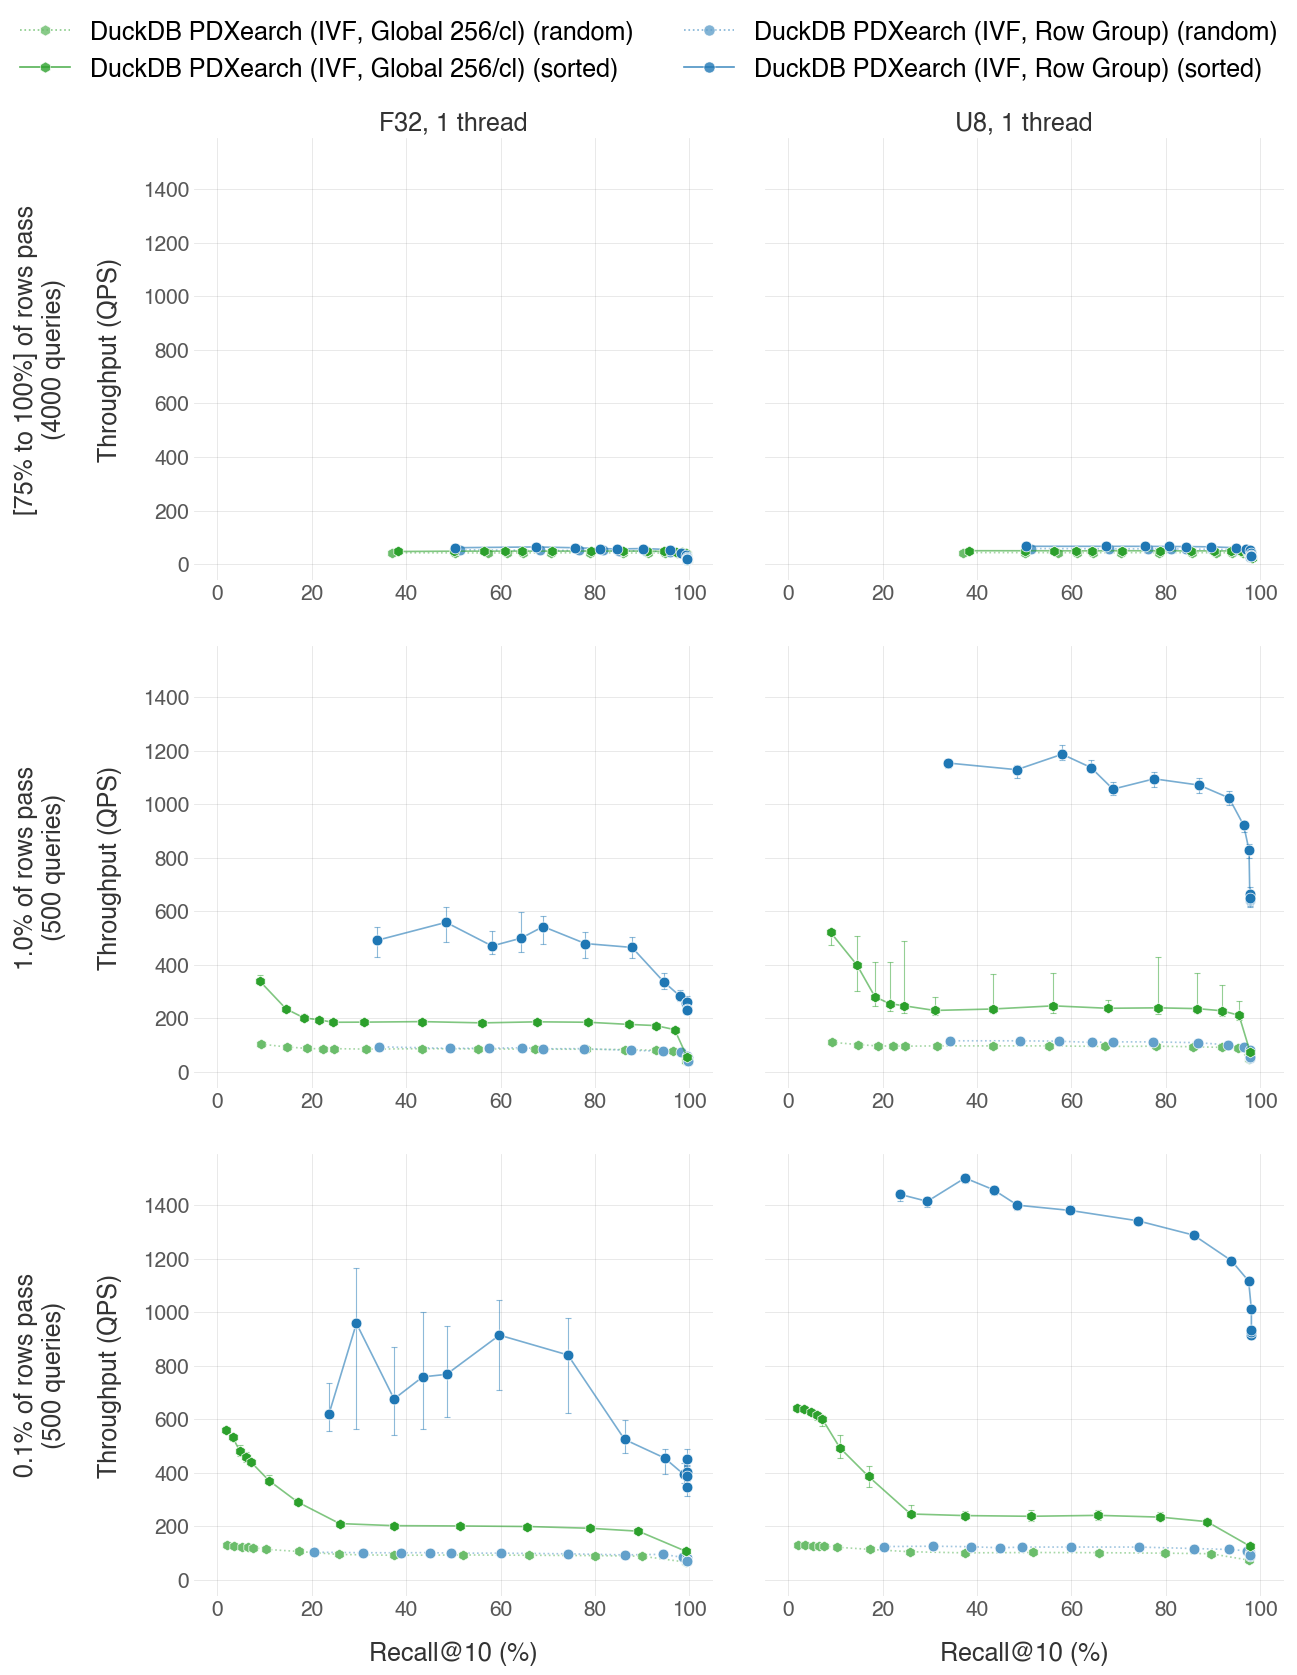

Saved index_filtered_search_cohere_blob_by_selectivity_f32_vs_u8_1t


In [5]:
# ---------------------------------------------------------------------------
# PDF 4: F32 1T vs U8 1T
# ---------------------------------------------------------------------------
f32_1_data, f32_1_idx = _filter_bucket_data([1], quant_filter="F32", remap_fn=_strip_quant)
u8_1_data, u8_1_idx = _filter_bucket_data([1], quant_filter="U8", remap_fn=_strip_quant)

# Merge ordered index lists
seen = set()
quant_1t_idx_ordered = []
for idx in f32_1_idx + u8_1_idx:
    if idx not in seen:
        quant_1t_idx_ordered.append(idx)
        seen.add(idx)

# Build legend using the stripped names (no "F32"/"U8")
quant_1t_legend = []
for index_type in quant_1t_idx_ordered:
    base_color = index_colors.get(index_type, "#808080")
    marker = index_markers.get(index_type, "o")
    for order_key, label_suffix, linestyle, lighten_amount, _ in DATASET_ORDERS:
        has_data = any(
            f32_1_data[1][order_key][b].get(index_type)
            or u8_1_data[1][order_key][b].get(index_type)
            for b in range(NUM_BUCKETS)
        )
        if not has_data:
            continue
        color = lighten(base_color, lighten_amount)
        quant_1t_legend.append(Line2D([0], [0], color=color, marker=marker, linestyle=linestyle,
                                    markersize=8, markeredgecolor='white', markeredgewidth=0.5,
                                    linewidth=1.2, alpha=0.8, label=f"{index_type} ({label_suffix})"))

# Combine F32 and U8 data into a single dict keyed by fake "thread counts"
# so the helper can iterate rows. Use 1 for F32 row, and a sentinel (10)
# for U8 row.
_SENTINEL_U8_1 = 10
combined_quant_1t_data: dict[int, dict[str, list[dict[str, list]]]] = {
    1: f32_1_data[1],
    _SENTINEL_U8_1: u8_1_data[1],
}

plot_selectivity_buckets(
    row_configs=[
        (1, "F32, 1 thread"),
        (_SENTINEL_U8_1, "U8, 1 thread"),
    ],
    all_idx_ordered=quant_1t_idx_ordered,
    filtered_records=combined_quant_1t_data,
    legend_handles=quant_1t_legend,
    filename="index_filtered_search_cohere_blob_by_selectivity_f32_vs_u8_1t",
)
